# 01 – Data Collection
**Examensarbete – Bull & Bear Market Detection**  
Viktor Emilsson & Loran Ali, Örebro Universitet 2026

---

I den här notebooken hämtar vi daglig OHLCV-data för:
- **S&P 500** (`^GSPC`) – amerikanskt aktieindex
- **Bitcoin** (`BTC-USD`) – kryptovaluta

**Period:** 2000-01-01 → 2026-01-01 S&P 500

**Period:** 2014-01-01 → 2026-01-01 BTC 

**Källa:** Yahoo Finance via `yfinance`

## 1. Importera bibliotek

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Plottinställningar
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Definiera tillgångar och tidsperiod

In [2]:
TICKERS = {
    'SP500':   '^GSPC',     
    'Bitcoin': 'BTC-USD',
}

START_SP500   = '2000-01-01'
START_BITCOIN = '2014-01-01'
END           = '2026-01-01'

DATA_DIR = '../data'
os.makedirs(DATA_DIR, exist_ok=True)

print(f'Tillgångar    : {list(TICKERS.keys())}')
print(f'Period SP500  : {START_SP500} → {END}')
print(f'Period BTC    : {START_BITCOIN} → {END}')
print(f'Data-mapp     : {DATA_DIR}')

Tillgångar    : ['SP500', 'Bitcoin']
Period SP500  : 2000-01-01 → 2026-01-01
Period BTC    : 2014-01-01 → 2026-01-01
Data-mapp     : ../data


In [3]:
import subprocess
subprocess.run(['pip', 'install', 'yfinance', '--upgrade', '--quiet'])

CompletedProcess(args=['pip', 'install', 'yfinance', '--upgrade', '--quiet'], returncode=0)

## 3. Hämta data från Yahoo Finance

Vi hämtar alla tillgängliga variabler (OHLCV):
- **Open** – öppningspris
- **High** – dagens högsta pris
- **Low** – dagens lägsta pris
- **Close** – stängningspris
- **Volume** – handelsvolym

In [4]:
def fetch_asset(name, ticker, start, end, retries=5, wait=60):
    """Hämtar OHLCV-data för en tillgång med automatiska återförsök."""
    for attempt in range(retries):
        try:
            df = yf.download(
                ticker,
                start=start,
                end=end,
                auto_adjust=True,
                progress=False,
                multi_level_index=False
            )
            if len(df) > 0:
                df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
                df.index.name = 'Date'
                df.index = pd.to_datetime(df.index).tz_localize(None)
                return df
            else:
                print(f'  Försök {attempt+1}/{retries} – tom data, väntar {wait}s...')
                time.sleep(wait)
        except Exception as e:
            print(f'  Försök {attempt+1}/{retries} – fel: {e}, väntar {wait}s...')
            time.sleep(wait)
    return pd.DataFrame()

print('Funktion redo.')

Funktion redo.


In [5]:
# Hämta alla tillgångar
assets = {}

START_PER_ASSET = {
    'SP500':   START_SP500,
    'Bitcoin': START_BITCOIN,
}

for name, ticker in TICKERS.items():
    start = START_PER_ASSET[name]
    print(f'\nHämtar {name} ({ticker})...')
    df = fetch_asset(name, ticker, start, END)
    
    if not df.empty:
        assets[name] = df
        print(f'  ✓ {len(df)} rader')
        print(f'  ✓ Period: {df.index.min().date()} → {df.index.max().date()}')
        print(f'  ✓ Kolumner: {list(df.columns)}')
    else:
        print(f'  ✗ Misslyckades')
    
    time.sleep(10)

print(f'\n✓ Hämtade {len(assets)}/{len(TICKERS)} tillgångar')


Hämtar SP500 (^GSPC)...
  ✓ 6539 rader
  ✓ Period: 2000-01-03 → 2025-12-31
  ✓ Kolumner: ['Open', 'High', 'Low', 'Close', 'Volume']

Hämtar Bitcoin (BTC-USD)...
  ✓ 4124 rader
  ✓ Period: 2014-09-17 → 2025-12-31
  ✓ Kolumner: ['Open', 'High', 'Low', 'Close', 'Volume']

✓ Hämtade 2/2 tillgångar


## 4. Utforska datan

In [6]:
# Visa första raderna för varje tillgång
for name, df in assets.items():
    print(f'\n── {name} ──────────────────────────────────')
    display(df.head())


── SP500 ──────────────────────────────────


,Open,High,Low,Close,Volume
Date,,,,,
2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,931800000
2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000
2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000
2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000
2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000



── Bitcoin ──────────────────────────────────


,Open,High,Low,Close,Volume
Date,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100


In [7]:
# Statistik för varje tillgång
for name, df in assets.items():
    print(f'\n── {name} – Statistik ──────────────────────')
    display(df.describe().round(2))


── SP500 – Statistik ──────────────────────


,Open,High,Low,Close,Volume
count,6539.00,6539.00,6539.00,6539.00,6.539000e+03
mean,2268.62,2281.55,2254.68,2268.95,3.418314e+09
std,1453.88,1460.55,1446.66,1454.14,1.513327e+09
min,679.28,695.27,666.79,676.53,0.000000e+00
25%,1210.12,1217.21,1202.70,1210.27,2.311660e+09
50%,1527.29,1533.74,1519.12,1526.75,3.529430e+09
75%,2891.17,2899.48,2876.70,2888.07,4.260655e+09
max,6936.02,6945.77,6921.60,6932.05,1.145623e+10



── Bitcoin – Statistik ──────────────────────


,Open,High,Low,Close,Volume
count,4124.00,4124.00,4124.00,4124.00,4.124000e+03
mean,26828.25,27368.67,26257.64,26848.34,2.163072e+10
std,31639.83,32181.99,31062.43,31650.55,2.288509e+10
min,176.90,211.73,171.51,178.10,5.914570e+06
25%,2690.98,2771.03,2613.84,2701.33,1.286307e+09
50%,10762.84,11022.06,10442.99,10765.19,1.708105e+10
75%,42200.93,43017.27,41396.10,42236.83,3.317551e+10
max,124752.14,126198.07,123196.05,124752.53,3.509679e+11


In [8]:
# Saknade värden
print('── Saknade värden ──────────────────────────')
for name, df in assets.items():
    missing = df.isnull().sum()
    print(f'\n{name}:')
    print(missing)

── Saknade värden ──────────────────────────

SP500:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Bitcoin:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


## 5. Visualisera stängningspriser

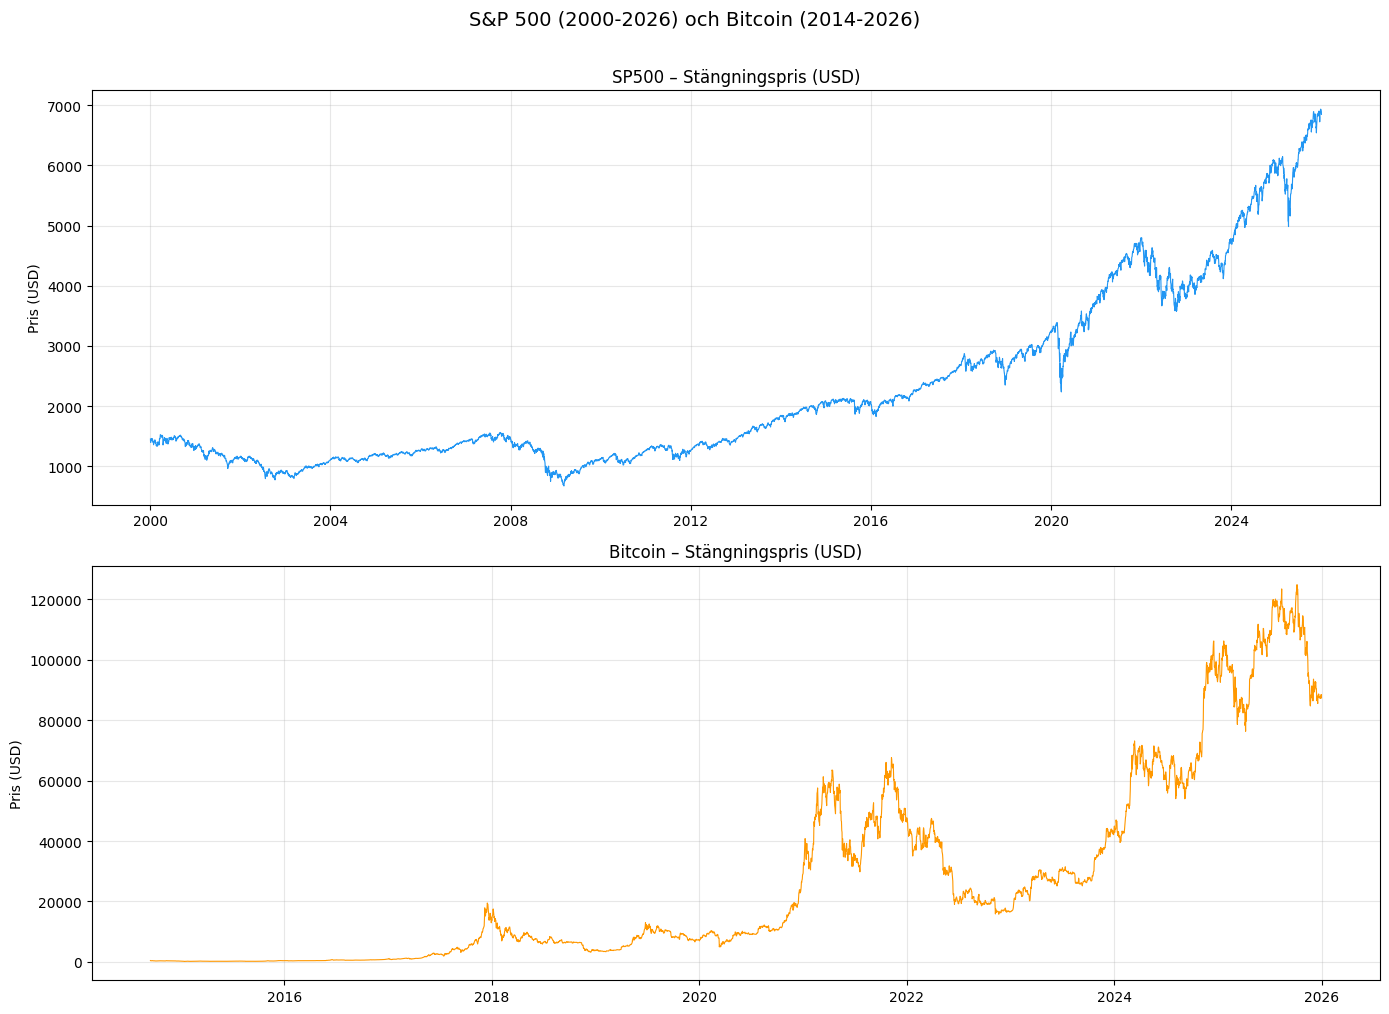

✓ Graf sparad: results/01_close_prices.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

colors = {'SP500': '#2196F3', 'Bitcoin': '#FF9800'}

for ax, (name, df) in zip(axes, assets.items()):
    ax.plot(df.index, df['Close'], color=colors[name], linewidth=0.8)
    ax.set_title(f'{name} – Stängningspris (USD)', fontsize=12)
    ax.set_ylabel('Pris (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('S&P 500 (2000-2026) och Bitcoin (2014-2026)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/01_close_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/01_close_prices.png')

## Normaliserad prisutveckling
För att jämföra tillgångarnas prisutveckling normaliserar vi alla priser till startindex = 100.
SP500 startar januari 2000, Bitcoin september 2014.
Y-axeln visar alltså procentuell förändring relativt respektive startpunkt.


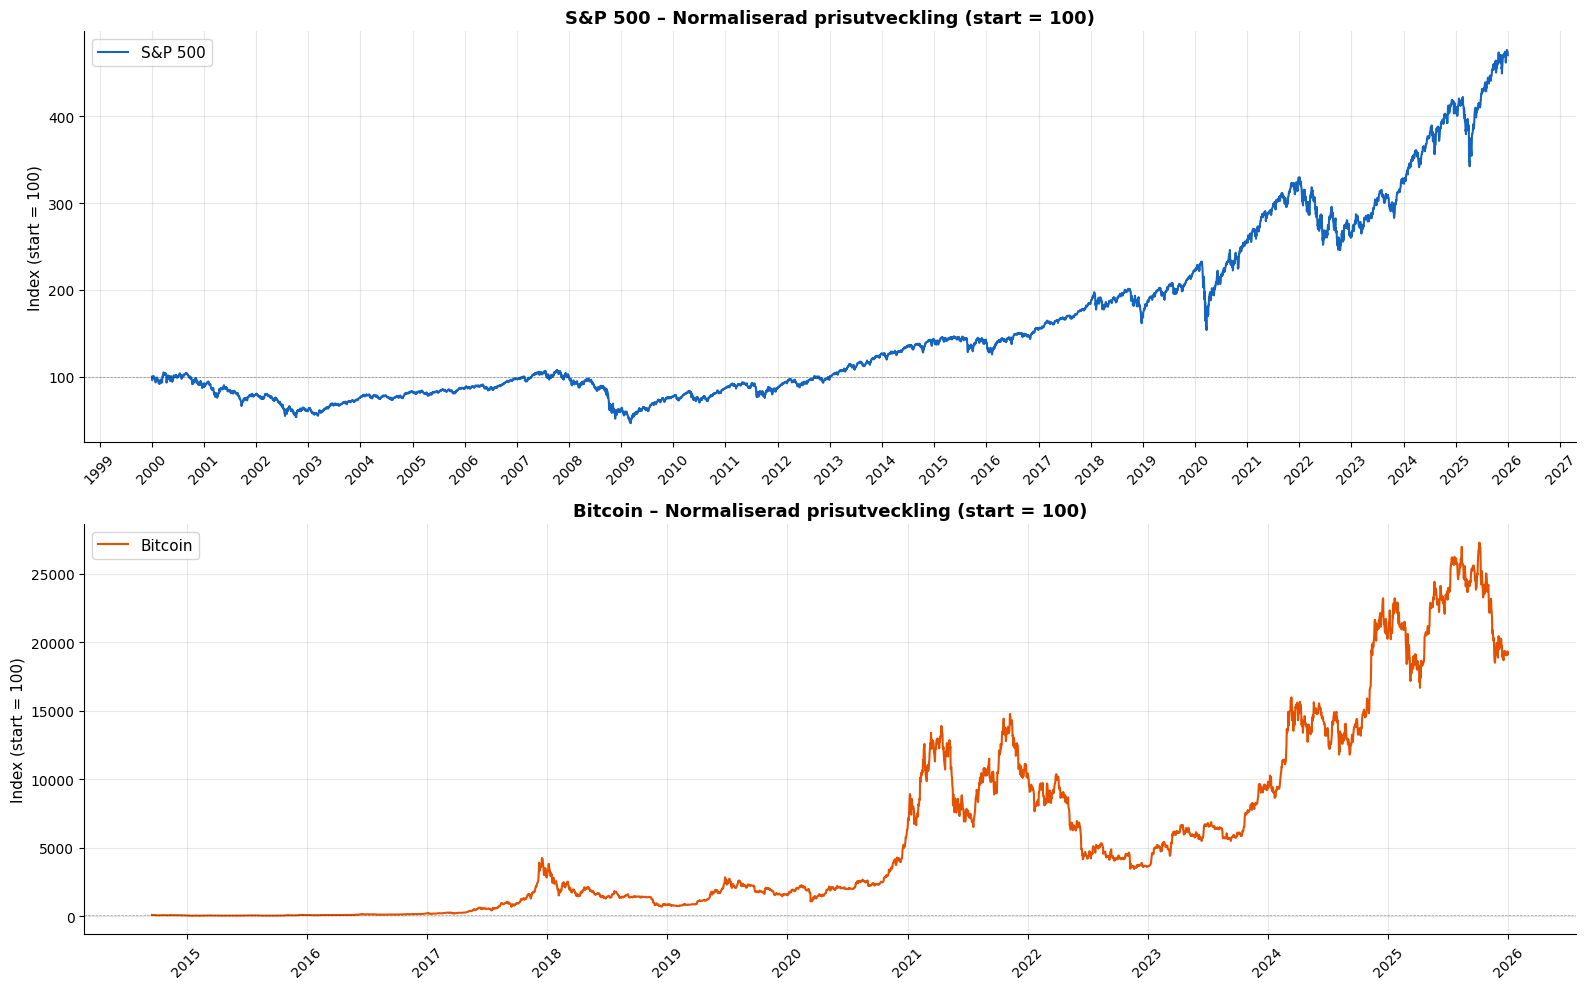

✓ Graf sparad: results/01_normalized_prices.png


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

colors = {'SP500': '#1565C0', 'Bitcoin': '#E65100'}
labels = {'SP500': 'S&P 500', 'Bitcoin': 'Bitcoin'}

# Övre graf: S&P 500
close_sp = assets['SP500']['Close'].dropna()
normalized_sp = (close_sp / close_sp.iloc[0]) * 100
ax1.plot(normalized_sp.index, normalized_sp, label=labels['SP500'],
         color=colors['SP500'], linewidth=1.5)
ax1.set_title('S&P 500 – Normaliserad prisutveckling (start = 100)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Index (start = 100)', fontsize=11)
ax1.axhline(100, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
ax1.legend(fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Nedre graf: Bitcoin
close_btc = assets['Bitcoin']['Close'].dropna()
normalized_btc = (close_btc / close_btc.iloc[0]) * 100
ax2.plot(normalized_btc.index, normalized_btc, label=labels['Bitcoin'],
         color=colors['Bitcoin'], linewidth=1.5)
ax2.set_title('Bitcoin – Normaliserad prisutveckling (start = 100)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Index (start = 100)', fontsize=11)
ax2.axhline(100, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
ax2.legend(fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/01_normalized_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/01_normalized_prices.png')

Vi delar upp i två separata grafer eftersom Bitcoins extrema tillväxt (~27 000% sedan 2014) gör det omöjligt att visa båda i samma graf – S&P 500 skulle knappt synas.

Separata grafer ger en tydligare bild av:

S&P 500 – långsiktig tillväxt med tydliga nedgångar vid kriser (dot-com 2000–2002, finanskrisen 2008–2009, covid 2020)

Bitcoin – extrem volatilitet med tydliga bull/bear-cykler

## 6. Spara data

In [11]:
os.makedirs('../results', exist_ok=True)

# Spara separata filer
for name, df in assets.items():
    filename = f'{name.lower()}.csv'
    filepath = os.path.join(DATA_DIR, filename)
    df.to_csv(filepath)
    print(f'✓ Sparad: data/{filename}  ({len(df)} rader)')

# Spara kombinerad fil
dfs_prefixed = []
for name, df in assets.items():
    df_p = df.copy()
    df_p.columns = [f'{name}_{col}' for col in df.columns]
    dfs_prefixed.append(df_p)

combined = pd.concat(dfs_prefixed, axis=1, sort=True)
combined.index.name = 'Date'
combined.to_csv(os.path.join(DATA_DIR, 'raw_prices.csv'))
print(f'\n✓ Kombinerad fil: data/raw_prices.csv')
print(f'  {combined.shape[0]} rader × {combined.shape[1]} kolumner')

✓ Sparad: data/sp500.csv  (6539 rader)
✓ Sparad: data/bitcoin.csv  (4124 rader)

✓ Kombinerad fil: data/raw_prices.csv
  7823 rader × 10 kolumner


## 7. Sammanfattning

| Tillgång | Ticker | Rader | Period | Variabler |
|----------|--------|-------|--------|-----------|
| S&P 500 | ^GSPC | ~6 539 | 2000–2026 | Open, High, Low, Close, Volume |
| Bitcoin | BTC-USD | ~4 124 | 2014–2026 | Open, High, Low, Close, Volume |

**Notering om saknade värden:**  
S&P 500 handlas bara på vardagar, Bitcoin handlas 7 dagar/vecka. 
Det innebär att det finns fler rader för Bitcoin. Detta hanteras i nästa notebook när vi slår ihop datan och droppar NaN.

**Nästa steg:** `02_labeling.ipynb` – skapa bull/bear-etiketter med 20%-regeln.